In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.stats.diagnostic import acorr_ljungbox

## Third experiment
### A SARIMAX model on the log-difference of gasoline prices

### 1. Load dataset and data wrangling

In [57]:
# Load the dataset
df = pd.read_csv('C:/Users/segar/OneDrive/Chicago/Winter_quarter/Time_Series/Final_project/time-series-gas-prices/data/master_df_geopolitics.csv')

# Display the first 5 rows to verify the columns
df.head()

df['Index'] = pd.to_datetime(df['Unnamed: 0'])

# Set it as the index of the dataframe
df.set_index('Index', inplace=True)

df.info()

# 1. Define the list of columns to be removed
# This includes the variables you identified and the individual import categories
cols_to_remove = [
    'Weekly_Gas_Price',
    'import_heavy_sour', 
    'import_heavy_sweet', 
    'import_light_sour', 
    'import_light_sweet', 
    'import_medium',
    'geopolitical_pulse_shock'
]

# 2. Drop the columns from the dataframe
# We also drop 'Unnamed: 0' since it is now redundant with the index
df_cleaned = df.drop(columns=cols_to_remove)

if 'Unnamed: 0' in df_cleaned.columns:
    df_cleaned.drop(columns=['Unnamed: 0'], inplace=True)

# 3. Ensure the index has a frequency (essential for SARIMAX)
# Assuming the data is monthly, we set it to 'MS' (Month Start) or 'M' (Month End)
df_cleaned.index = pd.to_datetime(df_cleaned.index)
df_cleaned = df_cleaned.asfreq('MS') 

# 4. Display the results
print("Remaining columns for the model:")
print(df_cleaned.columns.tolist())
print("\nDataframe Info:")
df_cleaned.info()
df_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 193 entries, 2010-01-01 to 2026-01-01
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                193 non-null    object 
 1   Gasoline_Stock            193 non-null    float64
 2   Monthly_Gas_Price         193 non-null    float64
 3   Weekly_Gas_Price          193 non-null    float64
 4   Core_Sticky_CPI           193 non-null    float64
 5   oil_production            193 non-null    float64
 6   import_heavy_sour         193 non-null    float64
 7   import_heavy_sweet        193 non-null    float64
 8   import_light_sour         193 non-null    float64
 9   import_light_sweet        193 non-null    float64
 10  import_medium             193 non-null    float64
 11  miles_traveled_nsa        193 non-null    float64
 12  miles_traveled_sa         193 non-null    float64
 13  total_imports             193 non-null    floa

,Gasoline_Stock,Monthly_Gas_Price,Core_Sticky_CPI,oil_production,miles_traveled_nsa,miles_traveled_sa,total_imports,total_crude_supply,covid_dummy,geopolitical_dummy
Index,,,,,,,,,,
2010-01-01,225636.60,2.715,1.170764,167529.0,220839.0,242519.0,1098272.0,1265801.0,0,1
2010-02-01,231405.75,2.644,1.048684,155496.0,210635.0,241803.0,1012600.0,1168096.0,0,1
2010-03-01,226422.25,2.772,0.925503,170976.0,254238.0,248076.0,1196132.0,1367108.0,0,1
2010-04-01,223452.80,2.848,0.869413,161769.0,253936.0,249112.0,1211344.0,1373113.0,0,1
2010-05-01,221144.25,2.836,0.793302,167427.0,256927.0,247042.0,1241584.0,1409011.0,0,1


### 2. Calculating log differences for target variable and non-stationary explanatory variables

In [58]:
df_transformed = df_cleaned.copy()

target = 'Monthly_Gas_Price'
df_transformed[target] = np.log(df_cleaned[target]).diff()

# 2. Check Exogenous Variables for Stationarity and Log-Difference if needed
dummies = ['covid_dummy', 'geopolitical_dummy']
explanatory_vars = [col for col in df_cleaned.columns if col not in dummies and col != target]

for col in explanatory_vars:
    # Run ADF test on the raw column
    p_value = adfuller(df_cleaned[col].dropna())[1]
    
    # If p-value > 0.05, it is non-stationary
    if p_value > 0.05:
        # Note: This assumes all values in the column are > 0. 
        df_transformed[col] = np.log(df_cleaned[col]).diff()
    else:
        # If already stationary, we leave it in its original level
        pass 

# Drop the first row (which is NaN due to differencing)
df_transformed.dropna(inplace=True)


# 3. Lag the Exogenous Variables (Shift by 1 to predict t using t-1)
y = df_transformed[target]
X = df_transformed.drop(columns=[target])

X_lagged = X.shift(1)
X_lagged.columns = [f'{col}_lag1' for col in X_lagged.columns]

# Recombine and drop the new NaN row created by shifting
df_final = pd.concat([y, X_lagged], axis=1).dropna()

### 3. Train/test split
#### 2025 is saved as a test set and the SARIMAX is estimated on 2010 - 2024

In [59]:
# 4. Train/Test Split (Isolating 2025 as the test set)
y_final = df_final[target]
X_final = df_final.drop(columns=[target])

y_train = y_final[:'2024-12-31']
y_test  = y_final['2025-01-01':]
X_train = X_final[:'2024-12-31']
X_test  = X_final['2025-01-01':]

print(f"Training months: {len(y_train)}")
print(f"Testing months (2025): {len(y_test)}")

Training months: 178
Testing months (2025): 13


### 4. Estimating the model with auto_arima

In [78]:
#removing some columns that were not significant in previous models or that are correlated one another
cols_to_drop = [
    'Core_Sticky_CPI_lag1',
    'miles_traveled_sa_lag1',      #i have the nsa version in the model
    'total_imports_lag1',
    'oil_production_lag1'  #production + imports = supply (which is already in the model)
]


# 2. Create the reduced training and testing sets
X_train_reduced = X_train.drop(columns=cols_to_drop)
X_test_reduced = X_test.drop(columns=cols_to_drop)

model_fit = pm.auto_arima(
    y_train, 
    X=X_train_reduced,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    m=12,             # Monthly seasonality (summer)
    d=0,              # d=0 because target is already differenced
    seasonal=True,
    start_P=0, 
    D=1,              # Let it test for seasonal differencing
    trace=True,
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True,
    with_intercept= True
)


print(model_fit.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=inf, Time=1.46 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-401.735, Time=0.10 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-439.697, Time=1.55 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=1.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-403.658, Time=0.29 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=-408.120, Time=0.52 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=-454.611, Time=2.61 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=4.68 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=3.10 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=-448.332, Time=3.87 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=-456.189, Time=4.65 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=-441.398, Time=3.21 sec
 ARIMA(2,0,0)(2,1,1)[12] intercept   : AIC=-488.574, Time=3.60 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=1.59 sec
 ARIMA(2,0,0)(2,1,2)[12] intercept   : AIC=i

## 5. Evaluating on the test set and calculate metrics

In [79]:
forecast_log_diff = model_fit.predict(n_periods=len(y_test), X=X_test_reduced)

# Inverse Transformation to get real prices
last_actual_price = df_cleaned[target].loc[y_train.index[-1]]
last_actual_log_price = np.log(last_actual_price)

forecast_log_prices = last_actual_log_price + forecast_log_diff.cumsum()

forecast_prices = np.exp(forecast_log_prices)

actual_prices_2025 = df_cleaned[target].loc[y_test.index]

mse = mean_squared_error(actual_prices_2025, forecast_prices)
mae = mean_absolute_error(actual_prices_2025, forecast_prices)
mape = np.mean(np.abs((actual_prices_2025 - forecast_prices) / actual_prices_2025)) * 100

print(f"--- Model Evaluation (2025 Test Set) ---")
print(f"Mean Absolute Error (MAE): ${mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

--- Model Evaluation (2025 Test Set) ---
Mean Absolute Error (MAE): $0.0958
Mean Squared Error (MSE): 0.0138
Mean Absolute Percentage Error (MAPE): 3.08%


### 6. Plotting a forecast

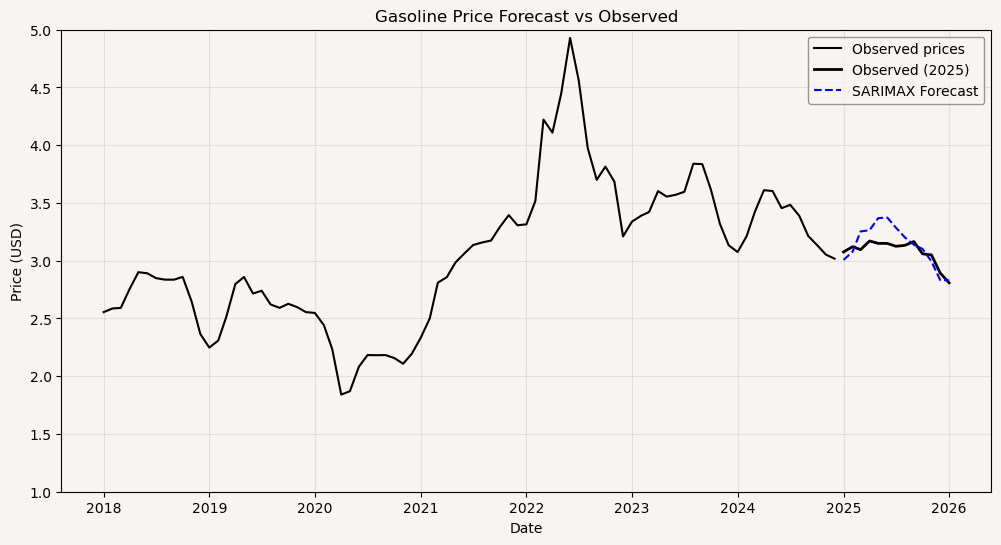

In [80]:
bg_color = "#f8f4f2" #same background color as the ppt slides

# 1. Create the figure and force the outer background (figure patch) to be pink
fig = plt.figure(figsize=(12, 6))
fig.patch.set_facecolor(bg_color) 

# 2. Force the inner plot area (axes) to be pink
ax = plt.gca()
ax.set_facecolor(bg_color)

# Plotting actuals from 2023 onward for context
plt.plot(df_cleaned[target].loc['2018':'2024-12-31'], label='Observed prices', color='black')
plt.plot(actual_prices_2025, label='Observed (2025)', color='black', linewidth=2)
plt.plot(forecast_prices, label='SARIMAX Forecast', color='blue', linestyle='--')

plt.ylim(1,5)
plt.title('Gasoline Price Forecast vs Observed')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

# 3. Force the legend background to be pink to match
plt.legend(facecolor=bg_color, edgecolor='gray')

plt.grid(True, alpha=0.3)
plt.show()

### 7. Evaluating the errors of the model

They show homosckedasticity and no serial correlation


--- Residual Analysis ---


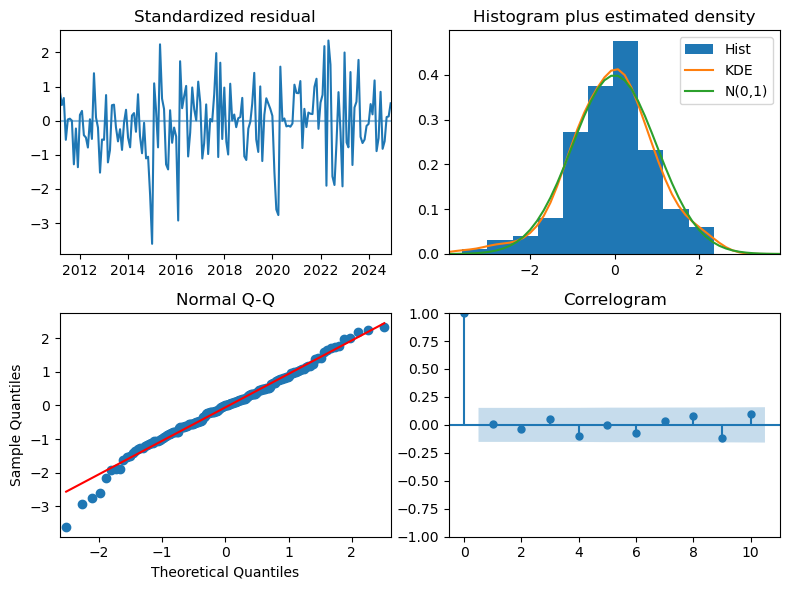

In [81]:
# 5. Error Analysis (Residual Diagnostics)
print("\n--- Residual Analysis ---")
model_fit.plot_diagnostics(figsize=(8, 6))
plt.tight_layout()
plt.show()